In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")

In [1]:
# -----------------------------------------------------------------------------
# Baseline provenance / notebook config
# -----------------------------------------------------------------------------

from pathlib import Path

WINNING_EXPERIMENT = "base_plus_engineered_hole"
MODEL_VERSION = "v1_catboost_expected_strokes_base_plus_engineered_hole"
TARGET_VARIABLE = "actual_strokes"
SPLIT_STRATEGY = "held_out_by_tourn_id"

# This should point to the scored residual export produced by the winning
# expected-strokes notebook.
RESIDUALS_PATH = Path.cwd() / "notebook_exports" / "catboost_expected_strokes_residuals_v1.parquet"

OUTPUT_DIR = Path.cwd() / "notebook_exports"
OUTPUT_DIR.mkdir(exist_ok=True)

WIND_SPEED_ORDER = ["calm", "light", "moderate", "strong"]
WIND_GUST_ORDER = ["low", "mild", "high", "very_high"]
DIVISION_ORDER = ["MA4", "MA3", "MA2", "MA1", "MPO"]

MIN_COURSE_ROWS = 100
MIN_TOURN_ROWS = 100

print("Using baseline:")
print("  experiment:", WINNING_EXPERIMENT)
print("  model_version:", MODEL_VERSION)
print("  target:", TARGET_VARIABLE)
print("  split_strategy:", SPLIT_STRATEGY)
print("  residuals_path:", RESIDUALS_PATH)


Using baseline:
  experiment: base_plus_engineered_hole
  model_version: v1_catboost_expected_strokes_base_plus_engineered_hole
  target: actual_strokes
  split_strategy: held_out_by_tourn_id
  residuals_path: c:\Users\ryanc\dg_wind_effects\wind_impact_analysis\notebook_exports\catboost_expected_strokes_residuals_v1.parquet


In [2]:
# -----------------------------------------------------------------------------
# Load scored residual dataset from the winning baseline notebook
# -----------------------------------------------------------------------------

import pandas as pd

residuals_df = pd.read_parquet(RESIDUALS_PATH)

print("Residual dataframe shape:", residuals_df.shape)
print("Columns:", residuals_df.columns.tolist())
residuals_df.head()


Residual dataframe shape: (1564744, 27)
Columns: ['event_year', 'tourn_id', 'round_number', 'hole_number', 'player_key', 'actual_strokes', 'target_strokes_over_par', 'player_rating', 'course_id', 'hole_length', 'hole_par', 'division', 'weather_available_flag', 'wind_speed_bucket', 'wind_speed_mps', 'wind_gust_mps', 'wind_dir_deg', 'temp_c', 'precip_mm', 'pressure_hpa', 'humidity_pct', 'expected_strokes', 'residual_strokes', 'abs_residual_strokes', 'model_name', 'model_version', 'split_seed']


,event_year,tourn_id,round_number,hole_number,player_key,actual_strokes,target_strokes_over_par,player_rating,course_id,hole_length,...,temp_c,precip_mm,pressure_hpa,humidity_pct,expected_strokes,residual_strokes,abs_residual_strokes,model_name,model_version,split_seed
0,2025,90001,1,1,PDGA#108871,4,0,911.0,241646,515.0,...,14.4,0.0,1020.4,76.0,4.296190,-0.296190,0.296190,catboost,prototype_v1,11
1,2025,90001,1,1,PDGA#121690,3,-1,997.0,241646,515.0,...,14.4,0.0,1020.4,76.0,3.684867,-0.684867,0.684867,catboost,prototype_v1,11
2,2025,90001,1,1,PDGA#126698,4,0,930.0,241646,515.0,...,14.4,0.0,1020.4,76.0,4.129436,-0.129436,0.129436,catboost,prototype_v1,11
3,2025,90001,1,1,PDGA#127239,4,0,922.0,241646,515.0,...,14.4,0.0,1020.4,76.0,4.132211,-0.132211,0.132211,catboost,prototype_v1,11
4,2025,90001,1,1,PDGA#132233,5,1,955.0,241646,515.0,...,14.4,0.0,1020.4,76.0,3.982817,1.017183,1.017183,catboost,prototype_v1,11


In [3]:
# -----------------------------------------------------------------------------
# Validate required columns
# -----------------------------------------------------------------------------

required_cols = [
    "event_year",
    "tourn_id",
    "round_number",
    "hole_number",
    "player_key",
    "actual_strokes",
    "expected_strokes",
    "residual_strokes",
    "player_rating",
    "course_id",
    "hole_length",
    "hole_par",
    "division",
    "wind_speed_mps",
    "wind_gust_mps",
    "wind_dir_deg",
]

missing = [c for c in required_cols if c not in residuals_df.columns]
if missing:
    raise ValueError(f"Residual dataset is missing required columns: {missing}")

print("Required columns present.")


Required columns present.


In [4]:
print(
    "Baseline notes:\n"
    "- winning baseline = base_plus_engineered_hole\n"
    "- slight positive global residual bias remains\n"
    "- mild residual structure remains in a few hole-length bins\n"
    "- sparse par-6 / rare-division groups are noisy\n"
    "- some course/tournament outliers remain\n"
)


Baseline notes:
- winning baseline = base_plus_engineered_hole
- slight positive global residual bias remains
- mild residual structure remains in a few hole-length bins
- sparse par-6 / rare-division groups are noisy
- some course/tournament outliers remain



In [5]:
# -----------------------------------------------------------------------------
# Wind feature engineering
# -----------------------------------------------------------------------------

import numpy as np
import pandas as pd

def wind_speed_bucket(speed: float | None) -> str:
    if pd.isna(speed):
        return "unknown"
    if speed < 2.0:
        return "calm"
    if speed < 5.0:
        return "light"
    if speed < 8.0:
        return "moderate"
    if speed < 12.0:
        return "strong"
    return "very_strong"


def wind_gust_bucket(speed: float | None) -> str:
    if pd.isna(speed):
        return "unknown"
    if speed < 3.0:
        return "low"
    if speed < 6.0:
        return "mild"
    if speed < 10.0:
        return "high"
    return "very_high"


def wind_dir_sector(deg: float | None) -> str:
    if pd.isna(deg):
        return "unknown"
    deg = float(deg) % 360.0
    if deg < 45 or deg >= 315:
        return "N"
    if deg < 135:
        return "E"
    if deg < 225:
        return "S"
    return "W"


def ordered_categorical(series: pd.Series, categories: list[str]) -> pd.Series:
    return pd.Categorical(series, categories=categories, ordered=True)


def interval_sort_key(x):
    if pd.isna(x):
        return (float("inf"), float("inf"))
    return (x.left, x.right)


residuals_df["abs_residual_strokes"] = residuals_df["residual_strokes"].abs()

residuals_df["wind_speed_bucket_v2"] = residuals_df["wind_speed_mps"].apply(wind_speed_bucket)
residuals_df["wind_gust_bucket"] = residuals_df["wind_gust_mps"].apply(wind_gust_bucket)
residuals_df["wind_dir_sector"] = residuals_df["wind_dir_deg"].apply(wind_dir_sector)

residuals_df["wind_speed_bucket_v2"] = ordered_categorical(residuals_df["wind_speed_bucket_v2"], WIND_SPEED_ORDER)
residuals_df["wind_gust_bucket"] = ordered_categorical(residuals_df["wind_gust_bucket"], WIND_GUST_ORDER)

residuals_df["hole_length_bin"] = pd.qcut(residuals_df["hole_length"], q=10, duplicates="drop")
residuals_df["player_rating_bin"] = pd.qcut(residuals_df["player_rating"], q=10, duplicates="drop")

residuals_df.head()


,event_year,tourn_id,round_number,hole_number,player_key,actual_strokes,target_strokes_over_par,player_rating,course_id,hole_length,...,residual_strokes,abs_residual_strokes,model_name,model_version,split_seed,wind_speed_bucket_v2,wind_gust_bucket,wind_dir_sector,hole_length_bin,player_rating_bin
0,2025,90001,1,1,PDGA#108871,4,0,911.0,241646,515.0,...,-0.296190,0.296190,catboost,prototype_v1,11,calm,mild,W,"(463.0, 1251.0]","(910.0, 924.0]"
1,2025,90001,1,1,PDGA#121690,3,-1,997.0,241646,515.0,...,-0.684867,0.684867,catboost,prototype_v1,11,calm,mild,W,"(463.0, 1251.0]","(961.0, 1059.0]"
2,2025,90001,1,1,PDGA#126698,4,0,930.0,241646,515.0,...,-0.129436,0.129436,catboost,prototype_v1,11,calm,mild,W,"(463.0, 1251.0]","(924.0, 940.0]"
3,2025,90001,1,1,PDGA#127239,4,0,922.0,241646,515.0,...,-0.132211,0.132211,catboost,prototype_v1,11,calm,mild,W,"(463.0, 1251.0]","(910.0, 924.0]"
4,2025,90001,1,1,PDGA#132233,5,1,955.0,241646,515.0,...,1.017183,1.017183,catboost,prototype_v1,11,calm,mild,W,"(463.0, 1251.0]","(940.0, 961.0]"


In [6]:
# -----------------------------------------------------------------------------
# Summary helper
# -----------------------------------------------------------------------------

def summarize_group(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    out = (
        df.groupby(group_cols, dropna=False, as_index=False, observed=False)
        .agg(
            rows=("actual_strokes", "size"),
            actual_mean=("actual_strokes", "mean"),
            expected_mean=("expected_strokes", "mean"),
            residual_mean=("residual_strokes", "mean"),
            residual_median=("residual_strokes", "median"),
            residual_std=("residual_strokes", "std"),
            mae=("abs_residual_strokes", "mean"),
            wind_speed_mean=("wind_speed_mps", "mean"),
            wind_gust_mean=("wind_gust_mps", "mean"),
        )
    )
    return out


In [8]:
# -----------------------------------------------------------------------------
# Overall wind effect
# -----------------------------------------------------------------------------

wind_speed_plot_df = residuals_df[residuals_df["wind_speed_bucket_v2"].isin(WIND_SPEED_ORDER)].copy()
wind_gust_plot_df = residuals_df[residuals_df["wind_gust_bucket"].isin(WIND_GUST_ORDER)].copy()

residuals_by_wind_speed_bucket = summarize_group(wind_speed_plot_df, ["wind_speed_bucket_v2"])
residuals_by_wind_gust_bucket = summarize_group(wind_gust_plot_df, ["wind_gust_bucket"])
residuals_by_wind_dir_sector = summarize_group(residuals_df, ["wind_dir_sector"])

residuals_by_wind_speed_bucket = residuals_by_wind_speed_bucket.sort_values("wind_speed_bucket_v2").reset_index(drop=True)
residuals_by_wind_gust_bucket = residuals_by_wind_gust_bucket.sort_values("wind_gust_bucket").reset_index(drop=True)

residuals_by_wind_speed_bucket, residuals_by_wind_gust_bucket

(  wind_speed_bucket_v2    rows  actual_mean  expected_mean  residual_mean  \
 0                 calm  600061     3.339529       3.358676      -0.019147   
 1                light  807449     3.385601       3.377671       0.007930   
 2             moderate  148203     3.500003       3.405880       0.094124   
 3               strong    9031     3.606688       3.425899       0.180789   
 
    residual_median  residual_std       mae  wind_speed_mean  wind_gust_mean  
 0        -0.071264      0.783784  0.583907         1.205819        3.280235  
 1        -0.049428      0.792517  0.588077         3.162986        6.747691  
 2         0.001210      0.834919  0.611905         5.969676       12.053063  
 3         0.063786      0.877794  0.649108         8.502491       16.540793  ,
   wind_gust_bucket    rows  actual_mean  expected_mean  residual_mean  \
 0              low  258724     3.331890       3.352978      -0.021087   
 1             mild  639030     3.338158       3.353000      -0.

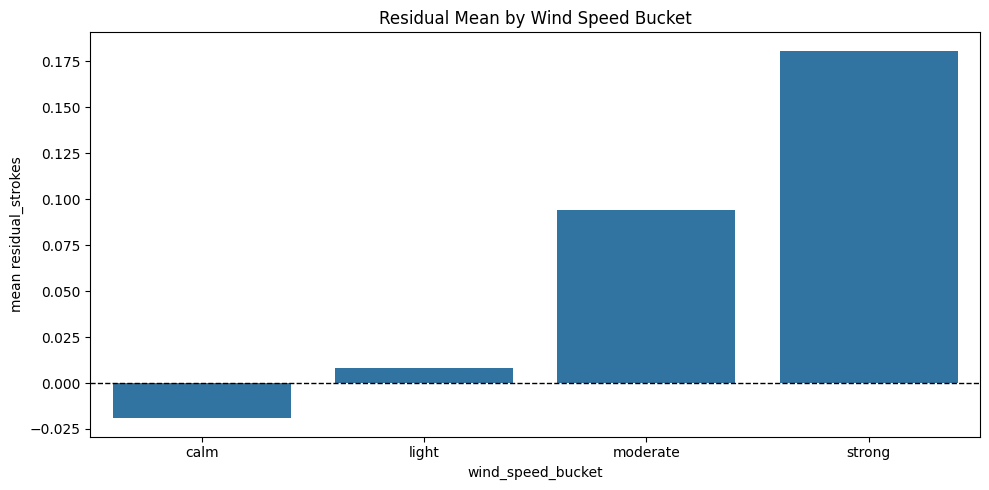

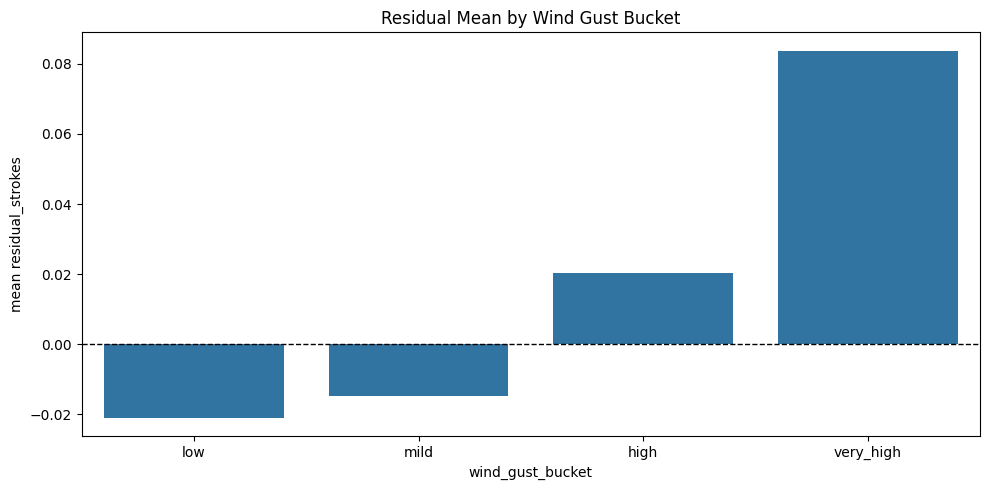

In [9]:
# Charts: overall wind effect

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(
    data=residuals_by_wind_speed_bucket,
    x="wind_speed_bucket_v2",
    y="residual_mean",
    order=WIND_SPEED_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Mean by Wind Speed Bucket")
plt.xlabel("wind_speed_bucket")
plt.ylabel("mean residual_strokes")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=residuals_by_wind_gust_bucket,
    x="wind_gust_bucket",
    y="residual_mean",
    order=WIND_GUST_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Mean by Wind Gust Bucket")
plt.xlabel("wind_gust_bucket")
plt.ylabel("mean residual_strokes")
plt.tight_layout()
plt.show()


In [10]:
# -----------------------------------------------------------------------------
# Wind effect by subgroup
# -----------------------------------------------------------------------------

course_wind_df = residuals_df[residuals_df["wind_speed_bucket_v2"].isin(WIND_SPEED_ORDER)].copy()

division_wind_df = residuals_df[
    residuals_df["division"].isin(DIVISION_ORDER) &
    residuals_df["wind_speed_bucket_v2"].isin(WIND_SPEED_ORDER)
].copy()

hole_par_wind_df = residuals_df[residuals_df["wind_speed_bucket_v2"].isin(WIND_SPEED_ORDER)].copy()
hole_length_wind_df = residuals_df[residuals_df["wind_speed_bucket_v2"].isin(WIND_SPEED_ORDER)].copy()
player_rating_wind_df = residuals_df[residuals_df["wind_speed_bucket_v2"].isin(WIND_SPEED_ORDER)].copy()
tourn_wind_df = residuals_df[residuals_df["wind_speed_bucket_v2"].isin(WIND_SPEED_ORDER)].copy()

residuals_by_course_and_wind = summarize_group(course_wind_df, ["course_id", "wind_speed_bucket_v2"])
residuals_by_division_and_wind = summarize_group(division_wind_df, ["division", "wind_speed_bucket_v2"])
residuals_by_hole_par_and_wind = summarize_group(hole_par_wind_df, ["hole_par", "wind_speed_bucket_v2"])
residuals_by_hole_length_bin_and_wind = summarize_group(hole_length_wind_df, ["hole_length_bin", "wind_speed_bucket_v2"])
residuals_by_player_rating_bin_and_wind = summarize_group(player_rating_wind_df, ["player_rating_bin", "wind_speed_bucket_v2"])
residuals_by_tourn_and_wind = summarize_group(tourn_wind_df, ["tourn_id", "wind_speed_bucket_v2"])

residuals_by_division_and_wind["division"] = ordered_categorical(
    residuals_by_division_and_wind["division"],
    DIVISION_ORDER,
)
residuals_by_division_and_wind = residuals_by_division_and_wind.sort_values(["division", "wind_speed_bucket_v2"]).reset_index(drop=True)

residuals_by_course_and_wind.head()



,course_id,wind_speed_bucket_v2,rows,actual_mean,expected_mean,residual_mean,residual_median,residual_std,mae,wind_speed_mean,wind_gust_mean
0,-1,calm,27990,3.513469,3.498301,0.015168,-0.080817,0.843628,0.627387,1.237464,3.490722
1,-1,light,40047,3.627712,3.585427,0.042285,-0.049627,0.825904,0.611563,3.296736,7.372879
2,-1,moderate,12890,3.645306,3.518613,0.126694,0.021942,0.858799,0.619890,6.153431,12.804919
3,-1,strong,882,3.821995,3.604132,0.217863,0.060447,0.908447,0.653128,8.313061,16.120408
4,200380,calm,702,2.816239,3.111057,-0.294818,-0.191279,0.576975,0.492618,1.067949,4.564103


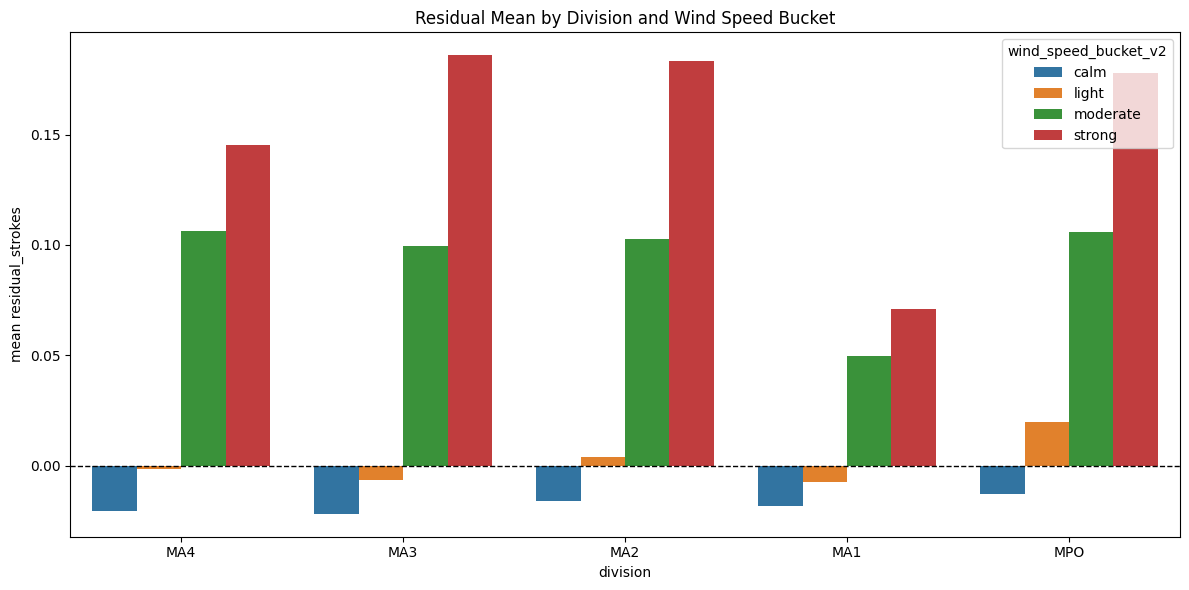

In [11]:
# -----------------------------------------------------------------------------
# Division-level wind impact chart
# -----------------------------------------------------------------------------

division_plot_df = residuals_by_division_and_wind.copy()
division_plot_df = division_plot_df[division_plot_df["division"].isin(DIVISION_ORDER)].copy()
division_plot_df["division"] = ordered_categorical(division_plot_df["division"], DIVISION_ORDER)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=division_plot_df,
    x="division",
    y="residual_mean",
    hue="wind_speed_bucket_v2",
    order=DIVISION_ORDER,
    hue_order=WIND_SPEED_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Mean by Division and Wind Speed Bucket")
plt.xlabel("division")
plt.ylabel("mean residual_strokes")
plt.tight_layout()
plt.show()



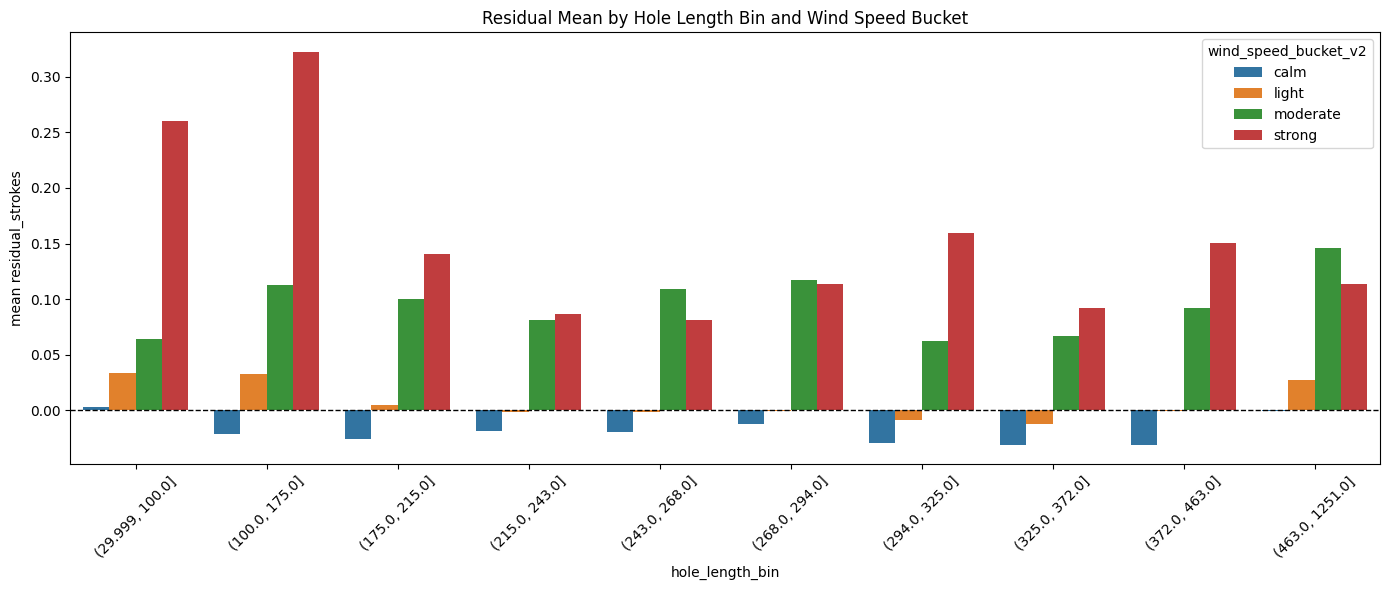

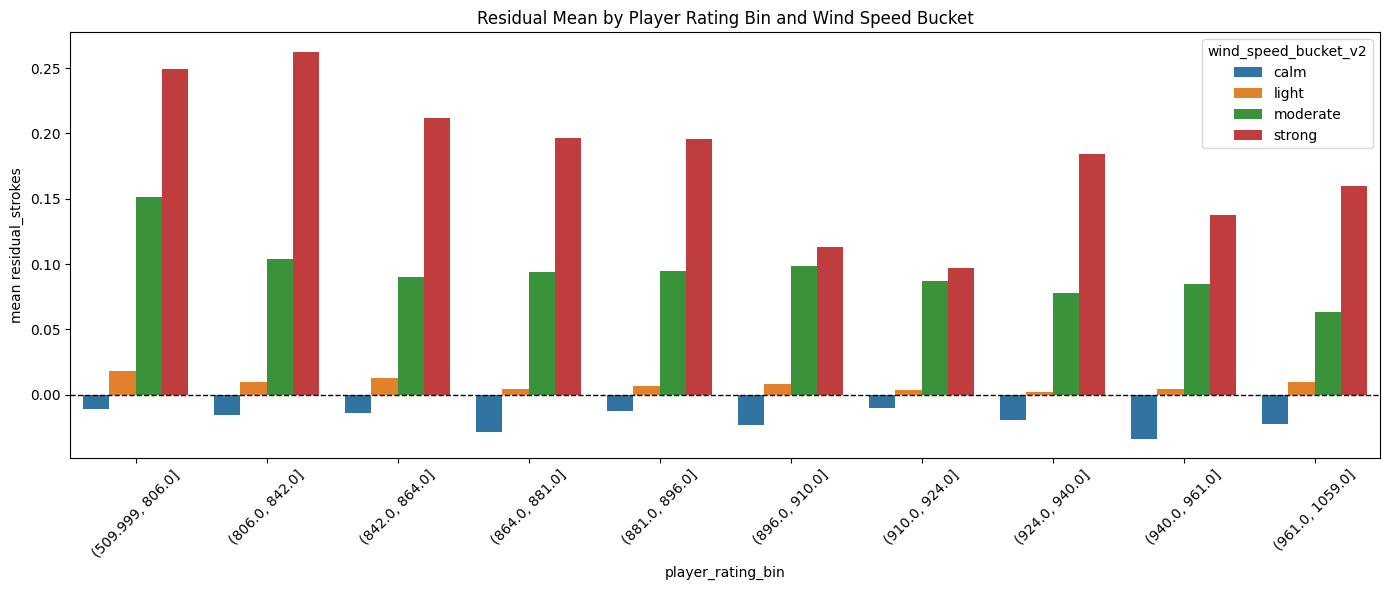

In [12]:
# -----------------------------------------------------------------------------
# Hole length and player rating sensitivity to wind
# -----------------------------------------------------------------------------

plot_df = residuals_by_hole_length_bin_and_wind.copy()
hole_length_bin_order = sorted(
    [x for x in plot_df["hole_length_bin"].dropna().unique()],
    key=interval_sort_key,
)
plot_df["hole_length_bin_str"] = plot_df["hole_length_bin"].astype(str)
hole_length_bin_order_str = [str(x) for x in hole_length_bin_order]

plt.figure(figsize=(14, 6))
sns.barplot(
    data=plot_df,
    x="hole_length_bin_str",
    y="residual_mean",
    hue="wind_speed_bucket_v2",
    order=hole_length_bin_order_str,
    hue_order=WIND_SPEED_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Mean by Hole Length Bin and Wind Speed Bucket")
plt.xlabel("hole_length_bin")
plt.ylabel("mean residual_strokes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plot_df = residuals_by_player_rating_bin_and_wind.copy()
player_rating_bin_order = sorted(
    [x for x in plot_df["player_rating_bin"].dropna().unique()],
    key=interval_sort_key,
)
plot_df["player_rating_bin_str"] = plot_df["player_rating_bin"].astype(str)
player_rating_bin_order_str = [str(x) for x in player_rating_bin_order]

plt.figure(figsize=(14, 6))
sns.barplot(
    data=plot_df,
    x="player_rating_bin_str",
    y="residual_mean",
    hue="wind_speed_bucket_v2",
    order=player_rating_bin_order_str,
    hue_order=WIND_SPEED_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Mean by Player Rating Bin and Wind Speed Bucket")
plt.xlabel("player_rating_bin")
plt.ylabel("mean residual_strokes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



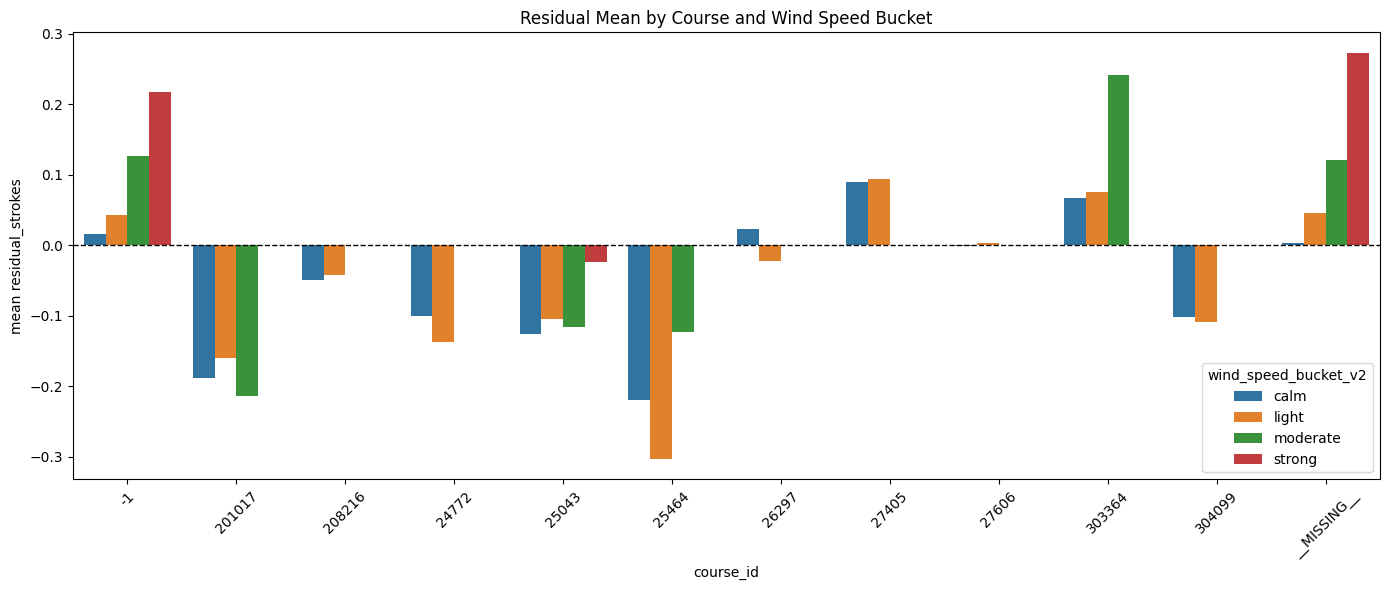

In [13]:
# -----------------------------------------------------------------------------
# Course-level wind impact chart
# -----------------------------------------------------------------------------

course_total_rows = (
    residuals_df.groupby("course_id", dropna=False)
    .size()
    .rename("course_total_rows")
    .reset_index()
)

course_plot_df = residuals_by_course_and_wind.merge(course_total_rows, on="course_id", how="left")
course_plot_df = course_plot_df[course_plot_df["course_total_rows"] >= MIN_COURSE_ROWS].copy()

top_courses = (
    course_plot_df[["course_id", "course_total_rows"]]
    .drop_duplicates()
    .sort_values("course_total_rows", ascending=False)
    .head(12)["course_id"]
    .tolist()
)

course_plot_df = course_plot_df[course_plot_df["course_id"].isin(top_courses)].copy()

plt.figure(figsize=(14, 6))
sns.barplot(
    data=course_plot_df,
    x="course_id",
    y="residual_mean",
    hue="wind_speed_bucket_v2",
    hue_order=WIND_SPEED_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Mean by Course and Wind Speed Bucket")
plt.xlabel("course_id")
plt.ylabel("mean residual_strokes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



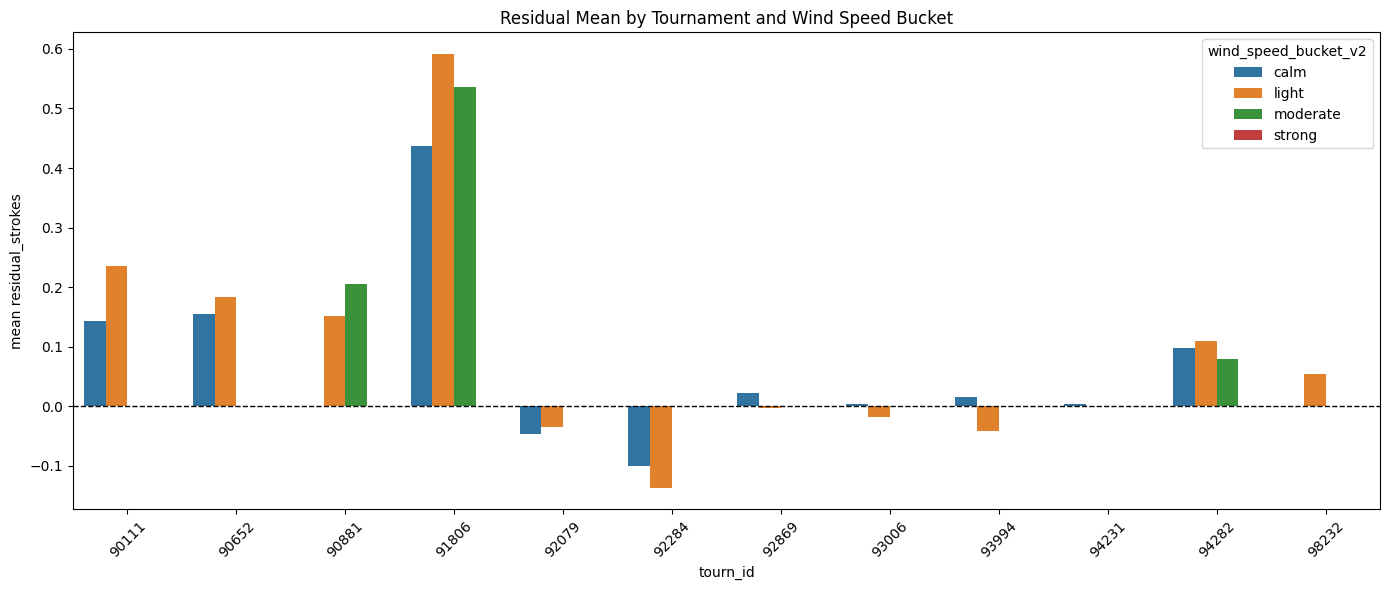

In [14]:
# -----------------------------------------------------------------------------
# Tournament-level wind impact chart
# -----------------------------------------------------------------------------

tourn_total_rows = (
    residuals_df.groupby("tourn_id", dropna=False)
    .size()
    .rename("tourn_total_rows")
    .reset_index()
)

tourn_plot_df = residuals_by_tourn_and_wind.merge(tourn_total_rows, on="tourn_id", how="left")
tourn_plot_df = tourn_plot_df[tourn_plot_df["tourn_total_rows"] >= MIN_TOURN_ROWS].copy()

top_tourns = (
    tourn_plot_df[["tourn_id", "tourn_total_rows"]]
    .drop_duplicates()
    .sort_values("tourn_total_rows", ascending=False)
    .head(12)["tourn_id"]
    .tolist()
)

tourn_plot_df = tourn_plot_df[tourn_plot_df["tourn_id"].isin(top_tourns)].copy()

plt.figure(figsize=(14, 6))
sns.barplot(
    data=tourn_plot_df,
    x="tourn_id",
    y="residual_mean",
    hue="wind_speed_bucket_v2",
    hue_order=WIND_SPEED_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Mean by Tournament and Wind Speed Bucket")
plt.xlabel("tourn_id")
plt.ylabel("mean residual_strokes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [15]:
# -----------------------------------------------------------------------------
# Compact wind signal summary
# -----------------------------------------------------------------------------

calm_baseline = residuals_by_wind_speed_bucket.loc[
    residuals_by_wind_speed_bucket["wind_speed_bucket_v2"] == "calm",
    "residual_mean"
]

calm_value = float(calm_baseline.iloc[0]) if len(calm_baseline) else np.nan

wind_signal_summary_df = residuals_by_wind_speed_bucket.copy()
wind_signal_summary_df["delta_from_calm"] = wind_signal_summary_df["residual_mean"] - calm_value

wind_signal_summary_df


,wind_speed_bucket_v2,rows,actual_mean,expected_mean,residual_mean,residual_median,residual_std,mae,wind_speed_mean,wind_gust_mean,delta_from_calm
0,calm,600061,3.339529,3.358676,-0.019147,-0.071264,0.783784,0.583907,1.205819,3.280235,0.000000
1,light,807449,3.385601,3.377671,0.007930,-0.049428,0.792517,0.588077,3.162986,6.747691,0.027077
2,moderate,148203,3.500003,3.405880,0.094124,0.001210,0.834919,0.611905,5.969676,12.053063,0.113271
3,strong,9031,3.606688,3.425899,0.180789,0.063786,0.877794,0.649108,8.502491,16.540793,0.199936


In [ ]:
# -----------------------------------------------------------------------------
# Export wind-impact analysis tables
# -----------------------------------------------------------------------------

residuals_by_wind_speed_bucket.to_csv(OUTPUT_DIR / "catboost_wind_impact_by_wind_speed_bucket_v1.csv", index=False)
residuals_by_wind_gust_bucket.to_csv(OUTPUT_DIR / "catboost_wind_impact_by_wind_gust_bucket_v1.csv", index=False)
residuals_by_wind_dir_sector.to_csv(OUTPUT_DIR / "catboost_wind_impact_by_wind_dir_sector_v1.csv", index=False)

residuals_by_tourn_and_wind.to_csv(OUTPUT_DIR / "catboost_wind_impact_by_tourn_and_wind_v1.csv", index=False)
residuals_by_course_and_wind.to_csv(OUTPUT_DIR / "catboost_wind_impact_by_course_and_wind_v1.csv", index=False)
residuals_by_division_and_wind.to_csv(OUTPUT_DIR / "catboost_wind_impact_by_division_and_wind_v1.csv", index=False)
residuals_by_hole_par_and_wind.to_csv(OUTPUT_DIR / "catboost_wind_impact_by_hole_par_and_wind_v1.csv", index=False)
residuals_by_hole_length_bin_and_wind.to_csv(OUTPUT_DIR / "catboost_wind_impact_by_hole_length_bin_and_wind_v1.csv", index=False)
residuals_by_player_rating_bin_and_wind.to_csv(OUTPUT_DIR / "catboost_wind_impact_by_player_rating_bin_and_wind_v1.csv", index=False)

wind_signal_summary_df.to_csv(OUTPUT_DIR / "catboost_wind_signal_summary_v1.csv", index=False)

print("Wrote wind-impact outputs to:", OUTPUT_DIR)

Wrote wind-impact outputs to: c:\Users\ryanc\dg_wind_effects\wind_impact_analysis\notebook_exports


: 